In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns

# Imports
from glue_sessions.glue_sessions import *
from licks import *

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

# Load behavioral data

In [ ]:
# df_behavior = pd.read_csv(r'C:\Users\Usuario\PycharmProjects\glue_sessions\2AFC_2\333.csv', low_memory=False)

In [3]:
# df_behavior = glue_animals(experiment='2AFC_2', update=False, to_csv=False)
df_behavior = glue_groups(['2AFC_2', '2AFC_3'])

# Filter data

In [87]:
# Filters for groups 1-3
# df_behavior = df_behavior[df_behavior.Stage == 4].reset_index(drop=True)
# df_behavior = df_behavior[df_behavior.Motor == 4].reset_index(drop=True)
df_behavior = df_behavior[df_behavior.P > 0].reset_index(drop=True)

# Filters for groups 4-5 (otherwise bump in lick rate before stimulus onset)
# df_behavior = df_behavior[df_behavior.Task == 'FD'].reset_index(drop=True)
# df_behavior = df_behavior[df_behavior.Delay == 0.5].reset_index(drop=True)

print(f'{round(len(df_behavior) / 1000)}k trials')

218k trials


# Add lick data

In [5]:
# Save old columns for comparison later
old_columns = list(df_behavior.columns)

# Add lick data to the DataFrame
df_behavior = add_lick_data(df_behavior)

# Print new columns added to the DataFrame
new_columns = list(df_behavior.columns)
new_columns = [col for col in new_columns if col not in old_columns]
print(new_columns)

0.16% of trials corrupted due to licks outside response window
['LicksLeft', 'LicksRight', 'nLicksLeft', 'nLicksRight', 'ILI_Left', 'ILI_Right', 'RT']


# Plot RTs distributions

## All trials

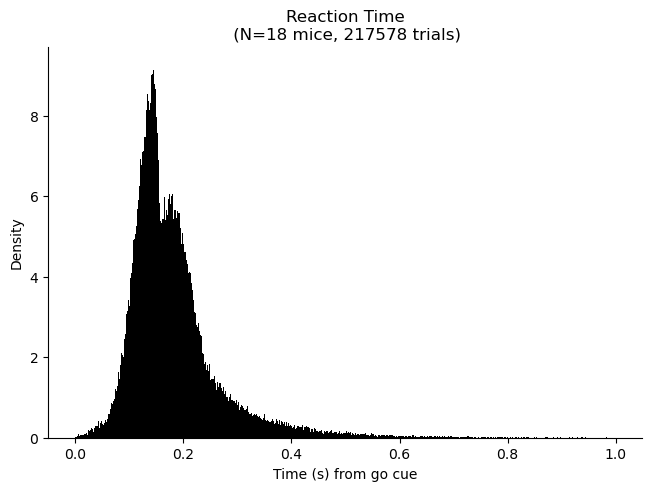

In [102]:
plot_rts(df_behavior, density=True)

There is a bimodal distribution of RTs across all mice. The overall distribution has a shoulder like second peak (lower) after the first one. It is likely due to the presence of two different strategies in the task: one that involves a fast response and another that involves a slower response.

An hypothesis is that the difference evidence levels (ILDs) drives different RTs. To examine this, we can plot a RT distribution per ILD level. To visually compare the distributions, a KDE plot is preferred.

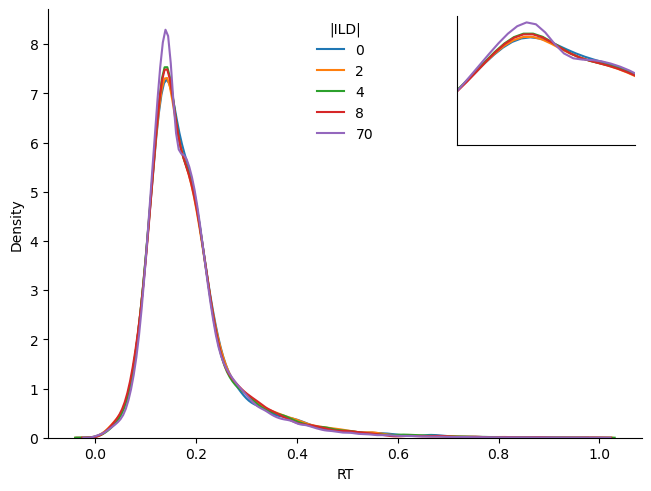

In [146]:
plt.figure(constrained_layout=True)

# Collapse the signed ILD levels to absolute values for cleaner visualization
df_behavior['absILD'] = df_behavior['ILD'].abs()
abs_ilds = sorted(df_behavior.absILD.unique().astype(int))

for ild in abs_ilds:
    df_ild = df_behavior[df_behavior.absILD == ild]
    sns.kdeplot(df_ild.RT, label=ild)

plt.xlabel('RT')
plt.ylabel('Density')
plt.legend(loc='upper center', frameon=False, title='|ILD|')
sns.despine()

# Zoomed inset on the peak of the distribution
ax = plt.gca()  # get current axes
ax_inset = inset_axes(ax, width="30%", height="30%", loc='upper right')
for ild in abs_ilds:
    df_ild = df_behavior[df_behavior.absILD == ild]
    sns.kdeplot(df_ild.RT, ax=ax_inset, label=ild)
ax_inset.set_xlim(0.1, 0.2)
sns.despine(ax=ax_inset)
ax_inset.set_xlabel('')
ax_inset.set_ylabel('')
ax_inset.set_xticklabels([])
ax_inset.set_yticklabels([])
ax_inset.tick_params(bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)

The ILD does not seem to explain the bimodality in the RT distribution. The bimodality is present across all ILD levels, suggesting that the bimodality is not driven by differences in evidence levels.

Another hypothesis is that the bimodality is driven by differences in behavioral variables such as outcome, choice, stimulus, repeat, or previous outcome. To examine this, we can plot a RT distribution per behavioral variable split in 2 conditions.

## Splits

### Outcome

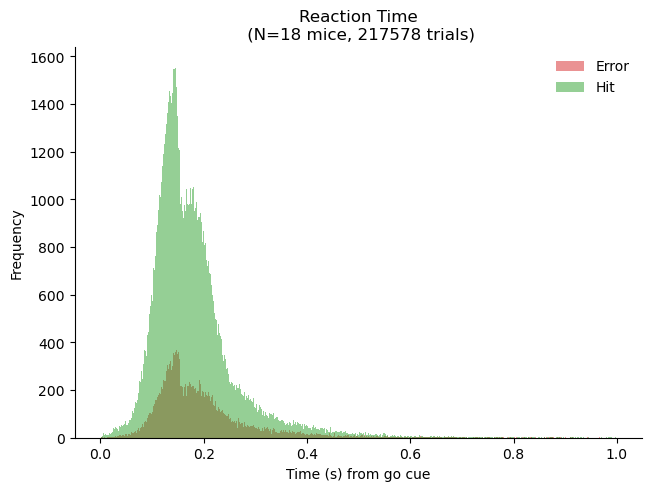

In [97]:
plot_rts_split(df_behavior, split='outcome', kind='hist')

### Choice

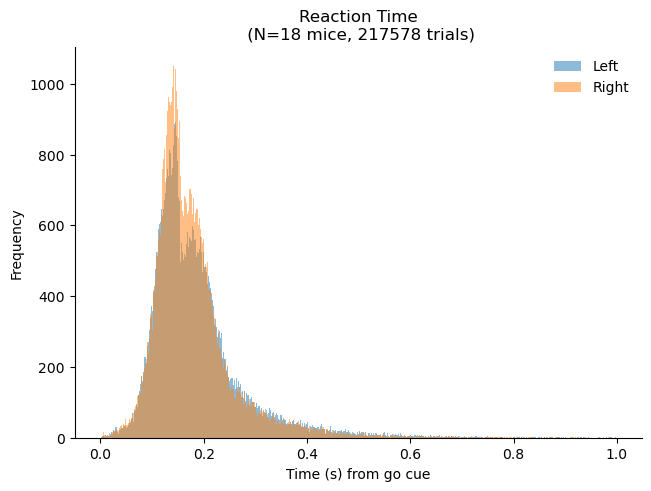

In [92]:
plot_rts_split(df_behavior, split='choice', kind='hist')

### Stimulus

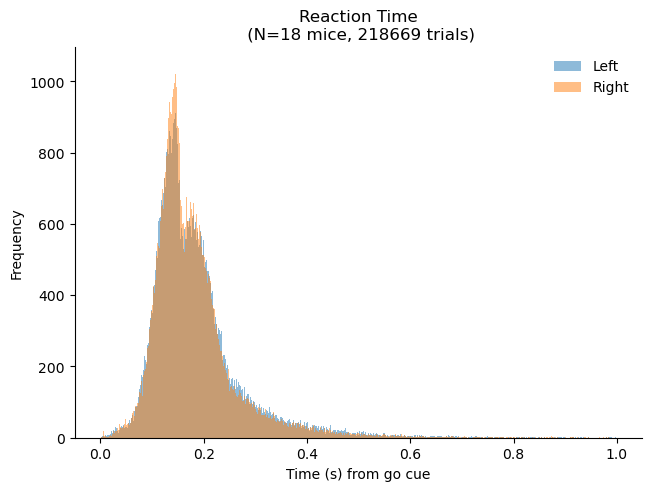

In [57]:
plot_rts_split(df_behavior, split='stim', kind='hist')

### Repeat

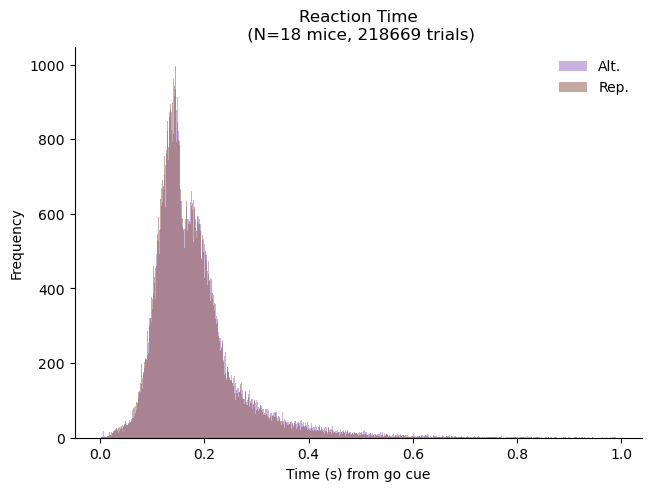

In [58]:
plot_rts_split(df_behavior, split='repeat', kind='hist')

### Previous outcome

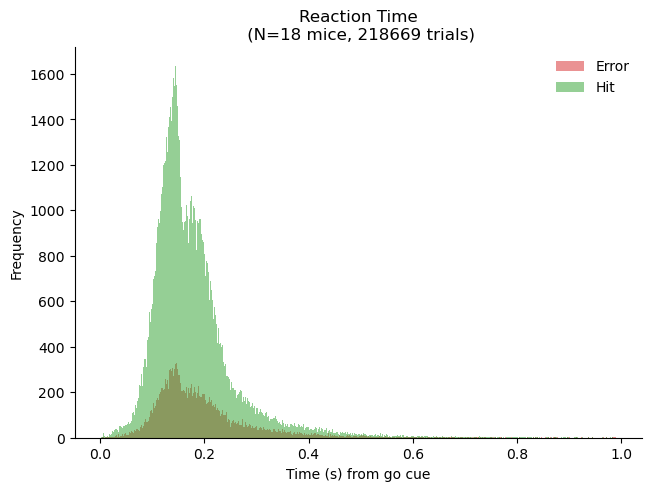

In [59]:
plot_rts_split(df_behavior, split='prev_out', kind='hist')

This bimodality can not be explained by differences in behavioral variables such as outcome, choice, stimulus, repeat, or previous outcome (see above).

Another possibility is that the bimodality reflects the a change in the internal state of the animal (e.g. motivation, reduced by satiatio as time passes) that is not captured by the behavioral variables. To examine this, we can split the data of each session into first and second half and plot the RT distribution for each half. If the bimodality is driven by a change in the internal state of the animal, we would expect to see a difference in the RT distribution between the first and second half of the session.

# Plot Chronometric Curves

## All trials

   abs_ILD        RT
0      0.0  0.186289
1      2.0  0.187186
2      4.0  0.185685
3      8.0  0.184547
4     70.0  0.182010


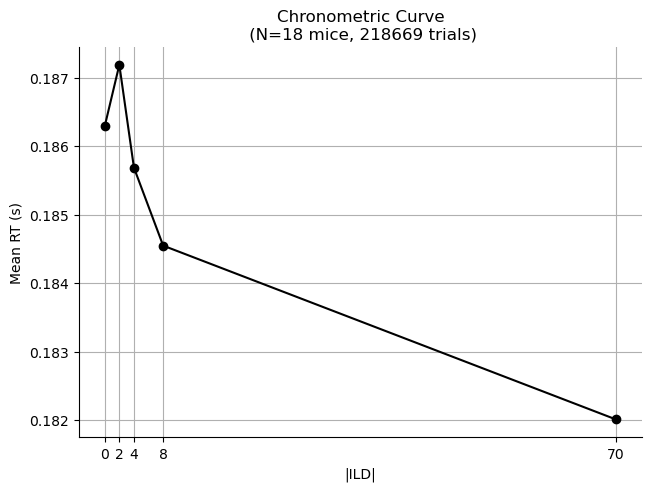

In [61]:
plot_chrono_curve(df_behavior, absolute=True)

## Splits

### Outcome

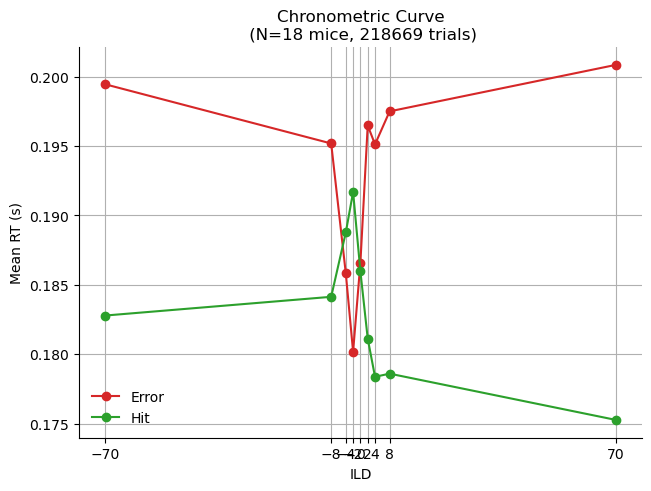

In [66]:
plot_chrono_curve_split(df_behavior, split='outcome', absolute=False)

### Choice

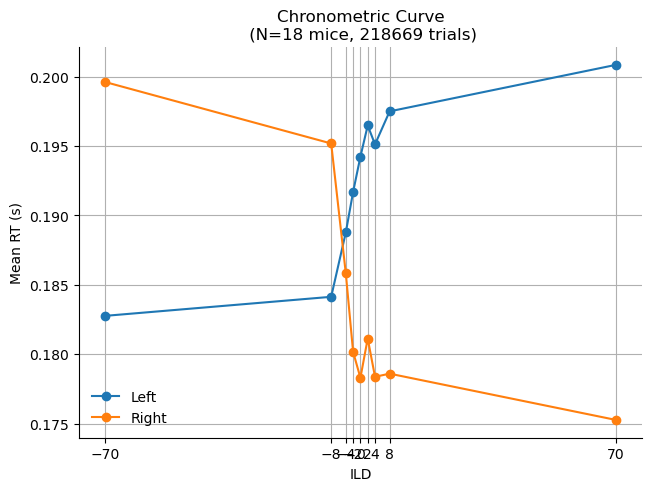

In [69]:
plot_chrono_curve_split(df_behavior, split='choice', absolute=False)

### Stimulus

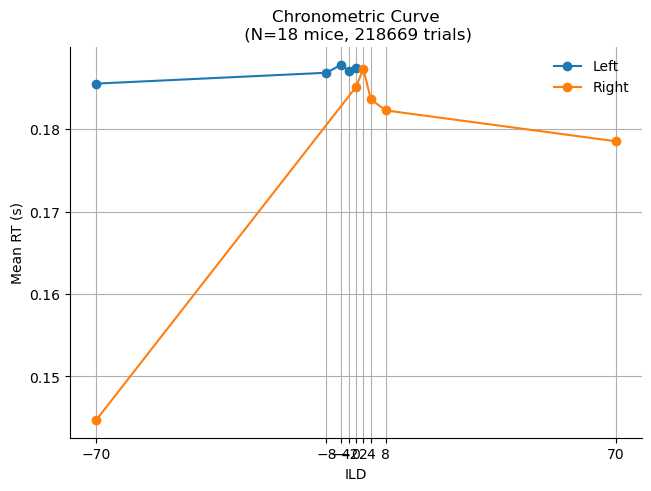

In [71]:
plot_chrono_curve_split(df_behavior, split='stim', absolute=False)

### Repeat

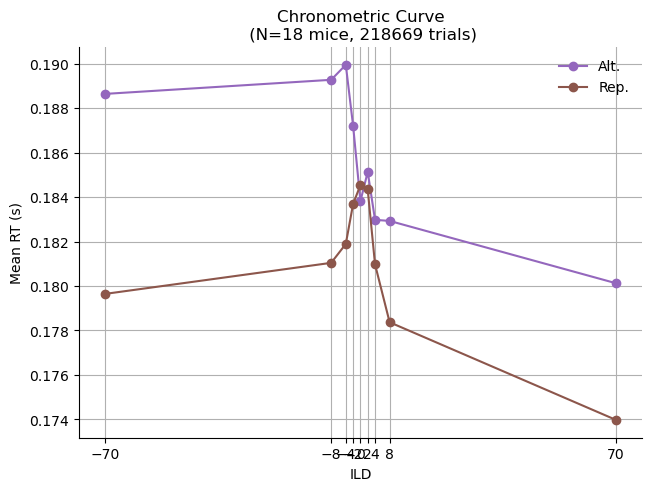

In [72]:
plot_chrono_curve_split(df_behavior, split='repeat', absolute=False)

### Previous outcome

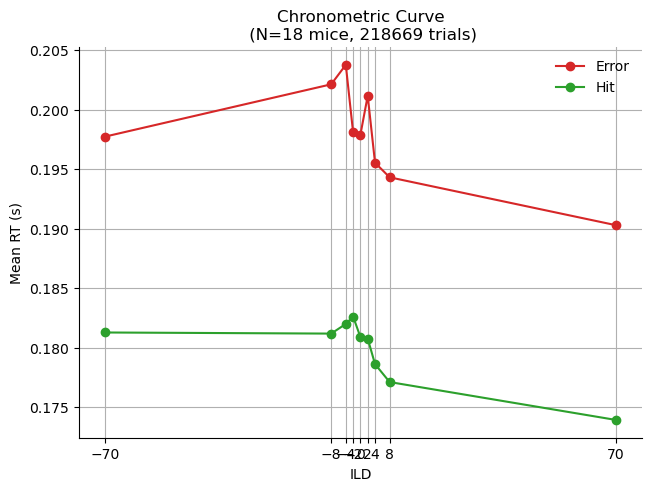

In [73]:
plot_chrono_curve_split(df_behavior, split='prev_out', absolute=False)

In [ ]:
# # Plot licks PSTH
# bins, left_psth = compute_psth(licks_left, time_win=[-1, 3], bin_size=0.1)
# bins, right_psth = compute_psth(licks_right, time_win=[-1, 3], bin_size=0.1)
# bins = bins[:-1]  # Remove the last bin edge to match the histogram length
# plot_licks_psth(bins, licks_left, licks_right)